# Goal

Explore recurring chart patterns to identify long-term dynamics in popular music.

The analyses focus on chart re-entries to uncover temporal and seasonal patterns and to generate hypotheses for subsequent analyses using Spotify metadata.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Load Datasets

project_path = Path.cwd().parent
interim_path = project_path / 'data' / 'interim'

chart_history = pd.read_csv(interim_path/'uk_chart_history_clean.csv')
songs = pd.read_csv(interim_path/'songs.csv')


In [3]:
chart_history.info()

<class 'pandas.DataFrame'>
RangeIndex: 210882 entries, 0 to 210881
Data columns (total 7 columns):
 #   Column          Non-Null Count   Dtype
---  ------          --------------   -----
 0   Song            210882 non-null  str  
 1   Artist          210882 non-null  str  
 2   Position        210882 non-null  int64
 3   Last Week       210882 non-null  str  
 4   Peak            210882 non-null  int64
 5   Weeks on Chart  210882 non-null  int64
 6   Week            210882 non-null  str  
dtypes: int64(3), str(4)
memory usage: 11.3 MB


In [4]:
songs.info()

<class 'pandas.DataFrame'>
RangeIndex: 36652 entries, 0 to 36651
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   song_id  36652 non-null  int64
 1   Song     36652 non-null  str  
 2   Artist   36652 non-null  str  
dtypes: int64(1), str(2)
memory usage: 859.2 KB


### Link Song Identifiers

Song identifiers are merged into the chart history to establish a stable relationship
between chart entries and song-based analyses.

In [5]:
chart_history = (chart_history.merge(songs,
                                     on=['Song', 'Artist'],
                                     how='left'))

chart_history = (chart_history[['song_id',
                                'Song',
                                'Artist',
                                'Position',
                                'Last Week',
                                'Peak',
                                'Weeks on Chart',
                                'Week']])

chart_history.head()

,song_id,Song,Artist,Position,Last Week,Peak,Weeks on Chart,Week
0,1,SAVE YOUR LOVE,RENEE AND RENATO,1,LW:1,1,11,2 January 1983- 8 January 1983
1,2,YOU CAN'T HURRY LOVE,PHIL COLLINS,2,LW:6,2,6,2 January 1983- 8 January 1983
2,3,A WINTER'S TALE,DAVID ESSEX,3,LW:7,3,5,2 January 1983- 8 January 1983
3,4,BEST YEARS OF OUR LIVES,MODERN ROMANCE,4,LW:8,4,9,2 January 1983- 8 January 1983
4,5,OUR HOUSE,MADNESS,5,LW:5,5,7,2 January 1983- 8 January 1983


## Explore Last Week Status

The `Last Week` column contains information about a song's chart status in the
previous week.

This section explores the distribution of these status values and identifies
chart re-entries (`LW:RE`) for further analysis.

In [6]:
# Explore Last Week Entries

chart_history['Last Week'].value_counts().head()

Last Week
LW:New    36401
LW:RE     10297
LW:1       2139
LW:8       2139
LW:6       2138
Name: count, dtype: int64

In [7]:
# Identify Re-Entries

re_entry_count = (chart_history['Last Week'] == 'LW:RE').sum()

print(f'Number of chart re-entries: {re_entry_count}')

Number of chart re-entries: 10297


### Count Re-entries per Song

Re-entry events are aggregated by song to identify titles that repeatedly
returned to the charts over the observation period.

In [8]:
re_entry = chart_history['Last Week'] == 'LW:RE'

re_entries = (chart_history.loc[re_entry,:]
              .groupby('song_id')
              .size()
              .sort_values(ascending=False))

re_entries.head(10)

song_id
24702    58
72       24
929      21
12530    20
28520    20
26511    19
28334    19
2738     19
27319    18
16731    18
dtype: int64

### Inspect the Most Frequent Re-entry

The song with the highest number of observed re-entries is identified to verify
the aggregation and provide an initial insight into long-term chart behaviour.

In [9]:
song_id = songs.loc[:, 'song_id'] == 24702.0
songs.loc[song_id, :]

,song_id,Song,Artist
24701,24702,MR BRIGHTSIDE,KILLERS


In [10]:
print(f'Songs with re-entries: {len(re_entries)}')

print(f'\nShare of songs with re-entries: {len(re_entries) / len(songs):.2%}')

Songs with re-entries: 6374

Share of songs with re-entries: 17.39%


## Create Re-entry History

All chart re-entry events are extracted into a separate dataset.

Only variables describing the individual re-entry event are retained, while
song-level statistics are handled separately in the chart statistics table.

This focused dataset serves as the basis for the following analyses of chart
positions, temporal patterns, and seasonal trends.

In [11]:
re_entry = chart_history.loc[:,'Last Week'] == 'LW:RE'

re_entry_history = chart_history.loc[re_entry, :].copy()

re_entry_history.head()

,song_id,Song,Artist,Position,Last Week,Peak,Weeks on Chart,Week
64,65,PASS THE DUTCHIE,MUSICAL YOUTH,65,LW:RE,1,13,2 January 1983- 8 January 1983
74,75,LET'S GO TO BED,THE CURE,75,LW:RE,44,5,2 January 1983- 8 January 1983
89,90,CAROLINE (LIVE AT THE N.E.C.),STATUS QUO,90,LW:RE,13,8,2 January 1983- 8 January 1983
90,91,THE LOOK OF LOVE,ABC,91,LW:RE,4,12,2 January 1983- 8 January 1983
93,94,CRY BOY CRY,BLUE ZOO,94,LW:RE,13,11,2 January 1983- 8 January 1983


### Data quality correction

The identified duplicate chart entries are removed before the analysis
datasets are created.

In [12]:
songs_to_delete = [{'song_id': 13494.0,
                    'Position': 57,
                    'Last Week': 'LW:New',
                    'Week': '3 September 1995- 9 September 1995',
                    'Run Start': 'NEW'},
                    {'song_id': 13494.0,
                     'Position': 76,
                     'Last Week': 'LW:57',
                     'Week': '10 September 1995- 16 September 1995',
                     'Run Start': ''},
                    {'song_id': 13963.0,
                     'Position': 91,
                     'Last Week': 'LW:New',
                     'Week': '24 December 1995- 30 December 1995',
                     'Run Start': 'NEW'},
                    {'song_id': 13964.0,
                     'Position': 61,
                     'Last Week': 'LW:New',
                     'Week': '17 December 1995- 23 December 1995',
                     'Run Start': 'NEW'},
                    {'song_id': 9153.0,
                     'Position': 19,
                     'Last Week': 'LW:New',
                     'Week': '3 January 1993- 9 January 1993',
                     'Run Start': 'NEW'},
                    {'song_id': 8801.0,
                     'Position': 21,
                     'Last Week': 'LW:New',
                     'Week': '18 August 1991- 24 August 1991',
                     'Run Start': 'NEW'},
                    {'song_id': 9059.0,
                     'Position': 22,
                     'Last Week': 'LW:New',
                     'Week': '24 November 1991- 30 November 1991',
                     'Run Start': 'NEW'},
                    {'song_id': 10317.0,
                     'Position': 24,
                     'Last Week': 'LW:New',
                     'Week': '31 January 1993- 6 February 1993',
                     'Run Start': 'NEW'},
                    {'song_id': 11077.0,
                     'Position': 36,
                     'Last Week': 'LW:New',
                     'Week': '17 October 1993- 23 October 1993',
                     'Run Start': 'NEW'},
                    {'song_id': 11000.0,
                     'Position': 29,
                     'Last Week': 'LW:New',
                     'Week': '19 September 1993- 25 September 1993',
                     'Run Start': 'NEW'}]

affected_song_ids = {item['song_id'] for item in songs_to_delete}

print(f'Number of affected songs: {len(affected_song_ids)}')

Number of affected songs: 9


In [13]:
print(f'Re-entry history rows before correction: {len(re_entry_history)}')

Re-entry history rows before correction: 10297


In [14]:
# Data quality correction

for item in songs_to_delete:
    mask = ((re_entry_history['song_id'] == item['song_id']) &
            (re_entry_history['Position'] == item['Position']) &
            (re_entry_history['Last Week'] == item['Last Week']) &
            (re_entry_history['Week'] == item['Week']))

    re_entry_history = re_entry_history.loc[~mask].copy()

In [15]:
print(f'Re-entry history rows after correction: {len(re_entry_history)}')

Re-entry history rows after correction: 10297


In [16]:
re_entry_history.info()

<class 'pandas.DataFrame'>
Index: 10297 entries, 64 to 210881
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   song_id         10297 non-null  int64
 1   Song            10297 non-null  str  
 2   Artist          10297 non-null  str  
 3   Position        10297 non-null  int64
 4   Last Week       10297 non-null  str  
 5   Peak            10297 non-null  int64
 6   Weeks on Chart  10297 non-null  int64
 7   Week            10297 non-null  str  
dtypes: int64(4), str(4)
memory usage: 724.0 KB


In [17]:
# Explore Re-entry Years

re_entry_history['Year'] = (re_entry_history['Week'].str[-4:].astype(int))

re_entry_history.head()

,song_id,Song,Artist,Position,Last Week,Peak,Weeks on Chart,Week,Year
64,65,PASS THE DUTCHIE,MUSICAL YOUTH,65,LW:RE,1,13,2 January 1983- 8 January 1983,1983
74,75,LET'S GO TO BED,THE CURE,75,LW:RE,44,5,2 January 1983- 8 January 1983,1983
89,90,CAROLINE (LIVE AT THE N.E.C.),STATUS QUO,90,LW:RE,13,8,2 January 1983- 8 January 1983,1983
90,91,THE LOOK OF LOVE,ABC,91,LW:RE,4,12,2 January 1983- 8 January 1983,1983
93,94,CRY BOY CRY,BLUE ZOO,94,LW:RE,13,11,2 January 1983- 8 January 1983,1983


In [18]:
re_1983 = re_entry_history['Year'] == 1983
print(f'Re-entries in 1983: {re_1983.sum()}')

re_1983_1984 = re_entry_history['Year'].between(1983, 1984)
print(f'\nRe-entries in 1983 and 1984: {re_1983_1984.sum()}')

Re-entries in 1983: 75

Re-entries in 1983 and 1984: 223


In [19]:
# Explore Re-entry Decades

re_entry_history['Decade'] = (re_entry_history['Year'] // 10) * 10

re_entry_history.head()

,song_id,Song,Artist,Position,Last Week,Peak,Weeks on Chart,Week,Year,Decade
64,65,PASS THE DUTCHIE,MUSICAL YOUTH,65,LW:RE,1,13,2 January 1983- 8 January 1983,1983,1980
74,75,LET'S GO TO BED,THE CURE,75,LW:RE,44,5,2 January 1983- 8 January 1983,1983,1980
89,90,CAROLINE (LIVE AT THE N.E.C.),STATUS QUO,90,LW:RE,13,8,2 January 1983- 8 January 1983,1983,1980
90,91,THE LOOK OF LOVE,ABC,91,LW:RE,4,12,2 January 1983- 8 January 1983,1983,1980
93,94,CRY BOY CRY,BLUE ZOO,94,LW:RE,13,11,2 January 1983- 8 January 1983,1983,1980


In [20]:
re_80s = re_entry_history['Decade'] == 1980

print(f'Re-entries in the 1980s: {re_80s.sum()}')

Re-entries in the 1980s: 974


### Explore Re-entry Positions

The chart positions of re-entry events are explored to understand where songs
typically return to the charts.

Summary statistics and the position distribution provide an initial overview of
this recurring chart pattern.

In [21]:
# Explore Re-Positions

re_entry_history['Position'].describe()

count    10297.000000
mean        80.851607
std         19.693226
min          1.000000
25%         74.000000
50%         87.000000
75%         95.000000
max        100.000000
Name: Position, dtype: float64

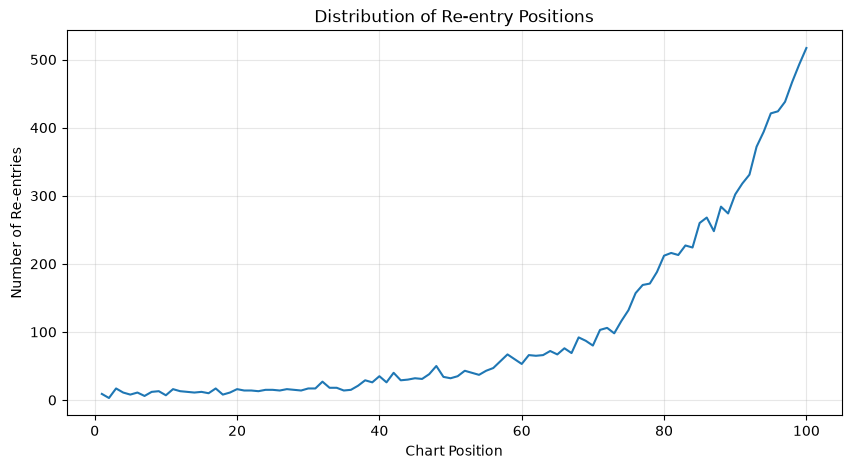

In [22]:
# Re-entry positions

re_position = (re_entry_history['Position'].value_counts().sort_index())

plt.figure(figsize=(10, 5))

plt.plot(re_position.index,
         re_position.values)

plt.title('Distribution of Re-entry Positions')
plt.xlabel('Chart Position')
plt.ylabel('Number of Re-entries')

plt.grid(alpha=0.3)

plt.show()

### Explore Re-entry Frequencies

The number of re-entries is calculated for each song to examine how frequently
songs return to the charts.

The resulting distribution highlights whether repeated chart re-entries are
common or represent exceptional cases.

In [ ]:
re_counts = re_entries.value_counts().sort_index()
re_counts.head()

1     4683
2     1000
3      303
4      128
5       73
6       41
7       35
8       26
9       17
10      10
11      15
12       6
13       9
14       5
15       1
16       4
17       7
18       3
19       3
20       2
21       1
24       1
58       1
Name: count, dtype: int64

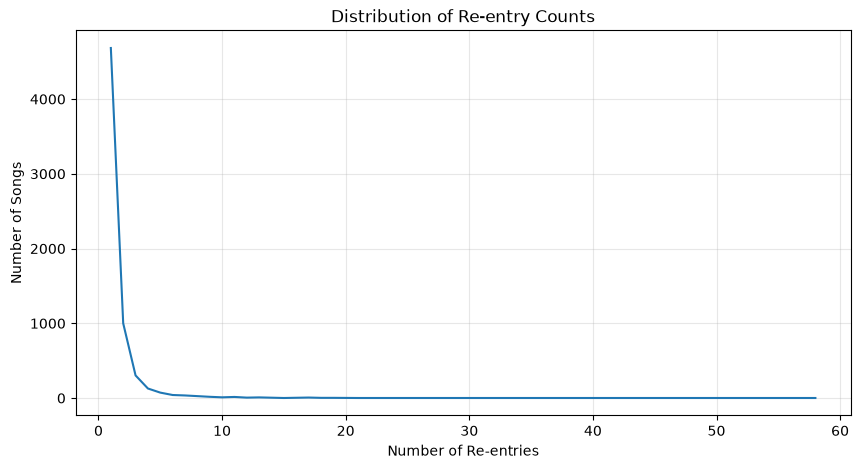

In [ ]:
# Re-entry counts

plt.figure(figsize=(10, 5))

plt.plot(re_counts.index,
         re_counts.values)

plt.title('Distribution of Re-entry Counts')
plt.xlabel('Number of Re-entries')

plt.ylabel('Number of Songs')

plt.grid(alpha=0.3)

plt.show()

In [25]:
# Most songs experience only a single chart re-entry, 
# while repeated re-entries are comparatively rare. 
# A small number of songs represent extreme long-term outliers.

### Identify Songs with Frequent Re-entries

Songs with the highest number of chart re-entries are identified to explore
which titles repeatedly return to the charts.

This provides an initial indication of long-term chart longevity.

In [26]:
top_re_songs = (re_entries.head(10)
                          .rename('number_re_entries')
                          .reset_index()
                          .merge(songs,
                                 on='song_id',
                                 how='left'))

top_re_songs

,song_id,number_re_entries,Song,Artist
0,24702,58,MR BRIGHTSIDE,KILLERS
1,72,24,MERRY XMAS EVERYBODY,SLADE
2,929,21,THRILLER,MICHAEL JACKSON
3,12530,20,STAY ANOTHER DAY,EAST 17
4,28520,20,USE SOMEBODY,KINGS OF LEON
5,26511,19,FAIRYTALE OF NEW YORK,POGUES FT KIRSTY MACCOLL
6,28334,19,ONE DAY LIKE THIS,ELBOW
7,2738,19,MERRY CHRISTMAS EVERYONE,SHAKIN' STEVENS
8,27319,18,DON'T STOP ME NOW,QUEEN
9,16731,18,I DON'T WANT TO MISS A THING,AEROSMITH


In [27]:
# Songs with frequent re-entries are predominantly long-lasting classics
# and seasonal titles, particularly Christmas songs.

### Explore Re-entry Activity over Time

The number of chart re-entries is aggregated by calendar year to examine how
re-entry activity changed throughout the observation period.

The resulting time series provides an initial overview of long-term temporal
patterns.

In [28]:
re_per_year = (re_entry_history.groupby('Year')
                               .size()
                               .rename('number_re_entries'))

re_per_year.head(15)

Year
1983     75
1984    148
1985    182
1986    205
1987    130
1988    134
1989    100
1990     86
1991     66
1992     20
1993     24
1994    146
1995    291
1996    332
1997    334
Name: number_re_entries, dtype: int64

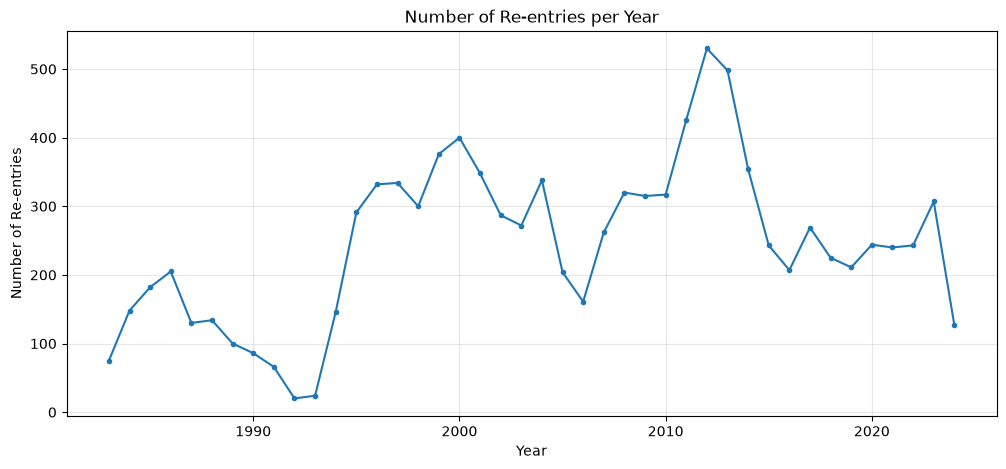

In [29]:
# Re-entries per Year

plt.figure(figsize=(12, 5))

plt.plot(re_per_year.index,
         re_per_year.values,
         marker='o',
         markersize=3)

plt.title('Number of Re-entries per Year')
plt.xlabel('Year')
plt.ylabel('Number of Re-entries')

plt.grid(alpha=0.3)

plt.show()

In [30]:
# The first years should be interpreted with caution because the observation
# period starts in 1983.

# Re-entry activity varies considerably over time. After a decline in the
# early 1990s, the number of re-entries increases substantially and reaches
# its highest levels around 2012.

# Technological changes may have influenced how songs re-enter the charts
# over time and represent a potential direction for further investigation.

### Explore Re-entry Seasonality

The chart week is used to derive the calendar month of each re-entry.

This enables an initial exploration of seasonal patterns in chart re-entries.

In [31]:
re_entry_history['Week'] = pd.to_datetime(re_entry_history['Week'].str.split('-').str[0],
format='%d %B %Y')

re_entry_history['Month'] = (re_entry_history['Week'].dt.month)

re_entry_history.head()

,song_id,Song,Artist,Position,Last Week,Peak,Weeks on Chart,Week,Year,Decade,Month
64,65,PASS THE DUTCHIE,MUSICAL YOUTH,65,LW:RE,1,13,1983-01-02,1983,1980,1
74,75,LET'S GO TO BED,THE CURE,75,LW:RE,44,5,1983-01-02,1983,1980,1
89,90,CAROLINE (LIVE AT THE N.E.C.),STATUS QUO,90,LW:RE,13,8,1983-01-02,1983,1980,1
90,91,THE LOOK OF LOVE,ABC,91,LW:RE,4,12,1983-01-02,1983,1980,1
93,94,CRY BOY CRY,BLUE ZOO,94,LW:RE,13,11,1983-01-02,1983,1980,1


In [32]:
re_per_month = (re_entry_history.groupby('Month')
                                .size()
                                .rename('number_re_entries'))

re_per_month

Month
1     1494
2      755
3      717
4      703
5      674
6      748
7      836
8      718
9      659
10     758
11     831
12    1404
Name: number_re_entries, dtype: int64

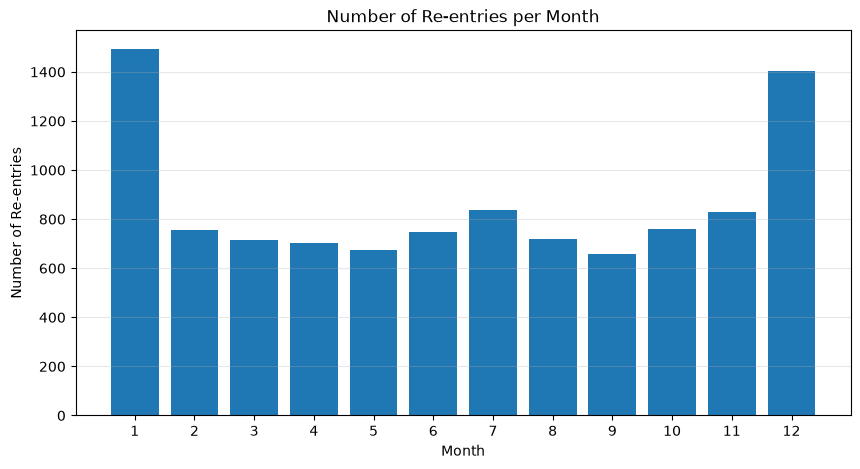

In [33]:
# Re-entries per Month

plt.figure(figsize=(10, 5))

plt.bar(re_per_month.index,
        re_per_month.values)

plt.title('Number of Re-entries per Month')
plt.xlabel('Month')
plt.ylabel('Number of Re-entries')

plt.xticks(range(1, 13))

plt.grid(axis='y', alpha=0.3)

plt.show()

In [34]:
# Re-entry activity shows a clear seasonal pattern. 
# January and December contain substantially more re-entries than the remaining months,
# indicating a strong seasonal influence on chart returns.

### Explore Re-entry Decades

Chart re-entries are aggregated by decade to examine long-term changes in
re-entry activity across different periods.

Since the observation period covers 1983 to March 2024, the first and last
decades are only partially represented and should be interpreted with caution.

In [35]:
re_per_decade = (re_entry_history.groupby('Decade')
                                 .size()
                                 .rename('number_re_entries'))

re_per_decade

Decade
1980     974
1990    1975
2000    2907
2010    3280
2020    1161
Name: number_re_entries, dtype: int64

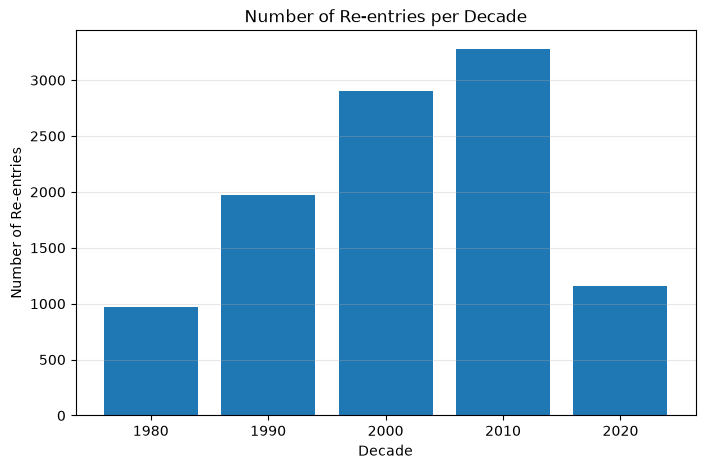

In [36]:
# Re-entries per Decade

plt.figure(figsize=(8, 5))

plt.bar(re_per_decade.index.astype(str),
        re_per_decade.values)

plt.title('Number of Re-entries per Decade')
plt.xlabel('Decade')
plt.ylabel('Number of Re-entries')

plt.grid(axis='y', alpha=0.3)

plt.show()

In [37]:
# Re-entry activity increased substantially from the 1980s to the 2010s.
# The lower numbers in the 1980s and 2020s should be interpreted with caution,
# as both decades are only partially covered by the observation period
# (1983–1989 and 2020–March 2024).

### Export Re-entry History

The enriched re-entry dataset is exported for reuse in subsequent analyses.

It contains all observed chart re-entry events together with the derived
temporal variables used throughout this notebook.

In [38]:
re_entry_history.head()

,song_id,Song,Artist,Position,Last Week,Peak,Weeks on Chart,Week,Year,Decade,Month
64,65,PASS THE DUTCHIE,MUSICAL YOUTH,65,LW:RE,1,13,1983-01-02,1983,1980,1
74,75,LET'S GO TO BED,THE CURE,75,LW:RE,44,5,1983-01-02,1983,1980,1
89,90,CAROLINE (LIVE AT THE N.E.C.),STATUS QUO,90,LW:RE,13,8,1983-01-02,1983,1980,1
90,91,THE LOOK OF LOVE,ABC,91,LW:RE,4,12,1983-01-02,1983,1980,1
93,94,CRY BOY CRY,BLUE ZOO,94,LW:RE,13,11,1983-01-02,1983,1980,1


## Explore New Entries

Chart runs beginning with a new chart entry are extracted into a separate dataset.

This allows the characteristics of new chart runs to be explored independently
from re-entries and provides a complementary perspective on chart dynamics.

In [39]:
new_entry = chart_history['Last Week'] == 'LW:New'

new_entry_history = (chart_history.loc[new_entry, :].copy())

new_entry_history.head()

,song_id,Song,Artist,Position,Last Week,Peak,Weeks on Chart,Week
37,38,DOWN UNDER,MEN AT WORK,38,LW:New,38,1,2 January 1983- 8 January 1983
39,40,EUROPEAN FEMALE,THE STRANGLERS,40,LW:New,40,1,2 January 1983- 8 January 1983
49,50,STEPPIN' OUT,JOE JACKSON,50,LW:New,50,1,2 January 1983- 8 January 1983
56,57,SNOWMAN MELODY,SNOWMEN,57,LW:New,57,1,2 January 1983- 8 January 1983
60,61,MY LOVE IS WAITING,MARVIN GAYE,61,LW:New,61,1,2 January 1983- 8 January 1983


### Data quality correction

The identified duplicate chart entries are removed before the analysis
datasets are created.

In [40]:
songs_to_delete = [{'song_id': 13494.0,
                    'Position': 57,
                    'Last Week': 'LW:New',
                    'Week': '3 September 1995- 9 September 1995',
                    'Run Start': 'NEW'},
                    {'song_id': 13494.0,
                     'Position': 76,
                     'Last Week': 'LW:57',
                     'Week': '10 September 1995- 16 September 1995',
                     'Run Start': ''},
                    {'song_id': 13963.0,
                     'Position': 91,
                     'Last Week': 'LW:New',
                     'Week': '24 December 1995- 30 December 1995',
                     'Run Start': 'NEW'},
                    {'song_id': 13964.0,
                     'Position': 61,
                     'Last Week': 'LW:New',
                     'Week': '17 December 1995- 23 December 1995',
                     'Run Start': 'NEW'},
                    {'song_id': 9153.0,
                     'Position': 19,
                     'Last Week': 'LW:New',
                     'Week': '3 January 1993- 9 January 1993',
                     'Run Start': 'NEW'},
                    {'song_id': 8801.0,
                     'Position': 21,
                     'Last Week': 'LW:New',
                     'Week': '18 August 1991- 24 August 1991',
                     'Run Start': 'NEW'},
                    {'song_id': 9059.0,
                     'Position': 22,
                     'Last Week': 'LW:New',
                     'Week': '24 November 1991- 30 November 1991',
                     'Run Start': 'NEW'},
                    {'song_id': 10317.0,
                     'Position': 24,
                     'Last Week': 'LW:New',
                     'Week': '31 January 1993- 6 February 1993',
                     'Run Start': 'NEW'},
                    {'song_id': 11077.0,
                     'Position': 36,
                     'Last Week': 'LW:New',
                     'Week': '17 October 1993- 23 October 1993',
                     'Run Start': 'NEW'},
                    {'song_id': 11000.0,
                     'Position': 29,
                     'Last Week': 'LW:New',
                     'Week': '19 September 1993- 25 September 1993',
                     'Run Start': 'NEW'}]


affected_song_ids = {item['song_id'] for item in songs_to_delete}

print(f'Number of affected songs: {len(affected_song_ids)}')

Number of affected songs: 9


In [41]:
print(f'New-entry history rows before correction: {len(new_entry_history)}')

New-entry history rows before correction: 36401


In [42]:
for item in songs_to_delete:
    mask = ((new_entry_history['song_id'] == item['song_id']) &
            (new_entry_history['Position'] == item['Position']) &
            (new_entry_history['Last Week'] == item['Last Week']) &
            (new_entry_history['Week'] == item['Week']))
    
    new_entry_history = new_entry_history.loc[~mask].copy()

In [43]:
print(f'New-entry history rows after correction: {len(new_entry_history)}')

New-entry history rows after correction: 36392


In [44]:
new_entry_history.info()

<class 'pandas.DataFrame'>
Index: 36392 entries, 37 to 210879
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   song_id         36392 non-null  int64
 1   Song            36392 non-null  str  
 2   Artist          36392 non-null  str  
 3   Position        36392 non-null  int64
 4   Last Week       36392 non-null  str  
 5   Peak            36392 non-null  int64
 6   Weeks on Chart  36392 non-null  int64
 7   Week            36392 non-null  str  
dtypes: int64(4), str(4)
memory usage: 2.5 MB


In [45]:
print(f'Number of new chart entries: {len(new_entry_history)}')

print(f'\nNumber of re chart entries: {len(re_entry_history)}')

Number of new chart entries: 36392

Number of re chart entries: 10297


In [46]:
### Explore New-entry Years

new_entry_history['Year'] = (new_entry_history['Week'].str[-4:].astype(int))

new_entry_history.head()

,song_id,Song,Artist,Position,Last Week,Peak,Weeks on Chart,Week,Year
37,38,DOWN UNDER,MEN AT WORK,38,LW:New,38,1,2 January 1983- 8 January 1983,1983
39,40,EUROPEAN FEMALE,THE STRANGLERS,40,LW:New,40,1,2 January 1983- 8 January 1983,1983
49,50,STEPPIN' OUT,JOE JACKSON,50,LW:New,50,1,2 January 1983- 8 January 1983,1983
56,57,SNOWMAN MELODY,SNOWMEN,57,LW:New,57,1,2 January 1983- 8 January 1983,1983
60,61,MY LOVE IS WAITING,MARVIN GAYE,61,LW:New,61,1,2 January 1983- 8 January 1983,1983


In [47]:
### Explore New-entry Decades

new_entry_history['Decade'] = (new_entry_history['Year'] // 10) * 10

new_entry_history.head()

,song_id,Song,Artist,Position,Last Week,Peak,Weeks on Chart,Week,Year,Decade
37,38,DOWN UNDER,MEN AT WORK,38,LW:New,38,1,2 January 1983- 8 January 1983,1983,1980
39,40,EUROPEAN FEMALE,THE STRANGLERS,40,LW:New,40,1,2 January 1983- 8 January 1983,1983,1980
49,50,STEPPIN' OUT,JOE JACKSON,50,LW:New,50,1,2 January 1983- 8 January 1983,1983,1980
56,57,SNOWMAN MELODY,SNOWMEN,57,LW:New,57,1,2 January 1983- 8 January 1983,1983,1980
60,61,MY LOVE IS WAITING,MARVIN GAYE,61,LW:New,61,1,2 January 1983- 8 January 1983,1983,1980


#### Prepare Calendar Features

The chart week is converted into a datetime format to derive calendar-based variables used in the following analyses.

In [48]:
### Explore New-entry Months

new_entry_history['Week'] = pd.to_datetime(new_entry_history['Week'].str.split('-').str[0], 
                                           format='%d %B %Y')

new_entry_history['Month'] = (new_entry_history['Week'].dt.month)

new_entry_history.head()

,song_id,Song,Artist,Position,Last Week,Peak,Weeks on Chart,Week,Year,Decade,Month
37,38,DOWN UNDER,MEN AT WORK,38,LW:New,38,1,1983-01-02,1983,1980,1
39,40,EUROPEAN FEMALE,THE STRANGLERS,40,LW:New,40,1,1983-01-02,1983,1980,1
49,50,STEPPIN' OUT,JOE JACKSON,50,LW:New,50,1,1983-01-02,1983,1980,1
56,57,SNOWMAN MELODY,SNOWMEN,57,LW:New,57,1,1983-01-02,1983,1980,1
60,61,MY LOVE IS WAITING,MARVIN GAYE,61,LW:New,61,1,1983-01-02,1983,1980,1


### Explore New-entry Positions

The distribution of chart positions is examined to understand where new chart
runs typically begin.

Summary statistics provide an initial overview, while the position distribution
reveals broader patterns across the chart.

In [49]:
# Explore New-Positions

new_entry_history['Position'].describe()

count    36392.000000
mean        53.600627
std         29.624332
min          1.000000
25%         28.000000
50%         55.000000
75%         80.000000
max        100.000000
Name: Position, dtype: float64

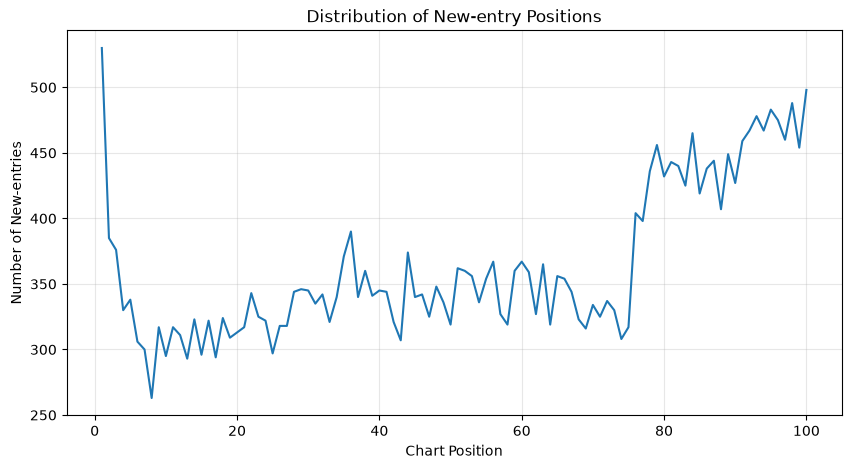

In [50]:
# New-entry positions

new_position = (new_entry_history['Position']
               .value_counts()
               .sort_index()
               )

plt.figure(figsize=(10, 5))

plt.plot(new_position.index,
         new_position.values)

plt.title('Distribution of New-entry Positions')
plt.xlabel('Chart Position')
plt.ylabel('Number of New-entries')

plt.grid(alpha=0.3)

plt.show()

In [51]:
# New entries occur across the entire chart.
# Position 1 forms a noticeable peak, while another concentration appears
# in the lower chart positions.

# Whether these patterns changed over time will be investigated later.

In [52]:
new_position.head(10)

Position
1     530
2     385
3     376
4     330
5     338
6     306
7     300
8     263
9     317
10    295
Name: count, dtype: int64

#### Validate Multiple New Chart Runs

Almost all songs begin only one chart run.

A very small number of songs start multiple new chart runs. This indicates that the same song can receive more than one `LW:New` entry in the dataset.

The chart rules leading to a new chart run remain subject to further investigation.

In [53]:
new_entry = chart_history['Last Week'] == 'LW:New'

new_entries = (chart_history.loc[new_entry, :]
               .groupby('song_id')
               .size())

new_entries.value_counts()

1    35685
2      335
3       11
4        2
5        1
Name: count, dtype: int64

In [54]:
top_new_songs = (new_entries[new_entries > 1]
                 .rename('number_new_entries')
                 .reset_index()
                 .merge(songs,
                        on='song_id',
                        how='left')
                .sort_values('number_new_entries',
                             ascending=False))

top_new_songs.head()

,song_id,number_new_entries,Song,Artist
37,6309,5,SATISFACTION,EVE
109,12210,4,SO IN LOVE WITH YOU,DUKE
11,1857,4,WHO'S THAT GIRL,EVE
101,11843,3,FEEL WHAT YOU WANT,KRISTINE W
92,11553,3,YOU GOTTA BE,DES'REE


In [55]:
# Eve's "Who's That Girl" illustrates that the same song can begin
# multiple independent chart runs in the dataset.

chart_history[chart_history['song_id'] == 1857]

,song_id,Song,Artist,Position,Last Week,Peak,Weeks on Chart,Week
9973,1857,WHO'S THAT GIRL,EVE,82,LW:New,82,1,25 November 1984- 1 December 1984
10062,1857,WHO'S THAT GIRL,EVE,71,LW:82,71,2,2 December 1984- 8 December 1984
10170,1857,WHO'S THAT GIRL,EVE,79,LW:71,71,3,9 December 1984- 15 December 1984
23571,1857,WHO'S THAT GIRL,EVE,3,LW:New,3,1,12 July 1987- 18 July 1987
23668,1857,WHO'S THAT GIRL,EVE,1,LW:3,1,2,19 July 1987- 25 July 1987
23769,1857,WHO'S THAT GIRL,EVE,2,LW:1,1,3,26 July 1987- 1 August 1987
23869,1857,WHO'S THAT GIRL,EVE,2,LW:2,1,4,2 August 1987- 8 August 1987
23975,1857,WHO'S THAT GIRL,EVE,8,LW:2,1,5,9 August 1987- 15 August 1987
24082,1857,WHO'S THAT GIRL,EVE,15,LW:8,1,6,16 August 1987- 22 August 1987
24187,1857,WHO'S THAT GIRL,EVE,20,LW:15,1,7,23 August 1987- 29 August 1987


In [56]:
# Compare chart duration at the start of a new chart run.
# LW\:New always starts at Week 1, while LW\:RE continues
# the song's existing chart history.

In [57]:
validation = (chart_history.groupby('Last Week')['Weeks on Chart']
              .agg(['min', 'max', 'median']))

validation.loc[['LW:New', 'LW:RE']]

,min,max,median
Last Week,,,
LW:New,1,1,1.0
LW:RE,2,391,11.0


In [58]:
# Validation:
# All NEW entries start with Weeks on Chart = 1,
# whereas RE entries continue an existing chart run.
#
# The conditions under which a completely new chart run begins
# require further investigation.

### Explore New-entry Years

The annual number of new chart entries is examined to identify long-term
changes in chart dynamics over time.

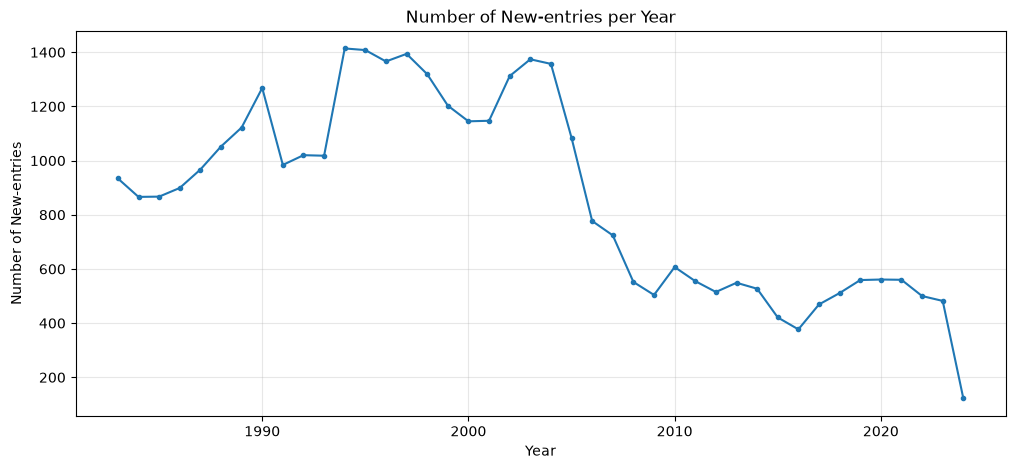

In [59]:
# New entries per year

new_per_year = (new_entry_history.groupby('Year')
                                 .size()
                                 .rename('number_new_entries'))

plt.figure(figsize=(12, 5))

plt.plot(new_per_year.index,
         new_per_year.values,
         marker='o',
         markersize=3)

plt.title('Number of New-entries per Year')
plt.xlabel('Year')
plt.ylabel('Number of New-entries')

plt.grid(alpha=0.3)

plt.show()

In [60]:
# The first years should be interpreted with caution because the observation
# period starts in 1983.

# New-entry activity increases during the 1990s before declining markedly
# from the mid-2000s onwards.

# The reasons behind this long-term trend require further investigation.

### Explore New-entry Seasonality

The monthly distribution of new chart entries is examined to identify
potential seasonal patterns throughout the year.

The results are compared with the previously observed re-entry seasonality.

In [61]:
new_per_month = (new_entry_history.groupby('Month')
                                  .size()
                                  .rename('number_new_entries'))

new_per_month

Month
1     2487
2     2928
3     3439
4     2918
5     3342
6     3151
7     2996
8     3028
9     3255
10    3358
11    3390
12    2100
Name: number_new_entries, dtype: int64

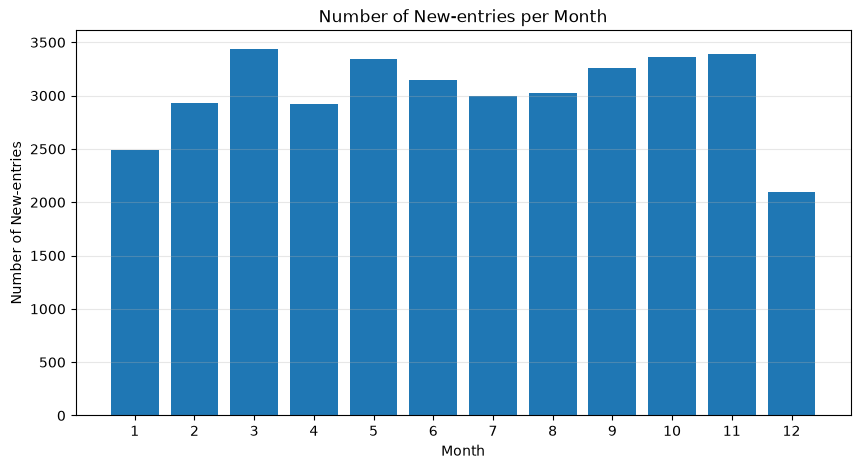

In [62]:
# New-entries per Month

plt.figure(figsize=(10, 5))

plt.bar(new_per_month.index,
        new_per_month.values)

plt.title('Number of New-entries per Month')
plt.xlabel('Month')
plt.ylabel('Number of New-entries')

plt.xticks(range(1, 13))

plt.grid(axis='y', alpha=0.3)

plt.show()

In [63]:
# New-entry activity is distributed much more evenly across the calendar year
# than re-entry activity.
#
# This contrasts with the pronounced winter peak observed for re-entries,
# where January and December dominate the seasonal distribution.

### Explore New-entry Decades

Long-term changes are summarised by decade to reduce year-to-year variation
and highlight broader trends in new chart activity.

#### New chart entries reached their highest levels during the 1990s and remained high throughout the 2000s.

Since the 2010s, the number of new chart entries has declined substantially.

The 2020s should be interpreted with caution because the observation period currently ends in 2024.

In [64]:
new_per_decade = (new_entry_history.groupby('Decade')
                                   .size()
                                   .rename('number_new_entries'))

new_per_decade

Decade
1980     6707
1990    12394
2000     9976
2010     5090
2020     2225
Name: number_new_entries, dtype: int64

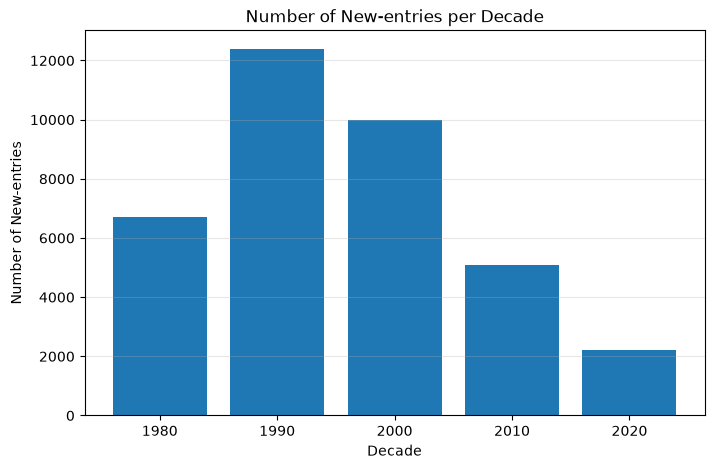

In [65]:
# New-entries per Decade

plt.figure(figsize=(8, 5))

plt.bar(new_per_decade.index.astype(str),
        new_per_decade.values)

plt.title('Number of New-entries per Decade')
plt.xlabel('Decade')
plt.ylabel('Number of New-entries')

plt.grid(axis='y', alpha=0.3)

plt.show()

In [66]:
# The 2020s should be interpreted with caution, as the observation period currently ends in 2024.

### Export New-entry History

The enriched new-entry dataset is exported for reuse in subsequent analyses.

It contains all observed new chart entries together with the derived
temporal variables used throughout this notebook.

In [67]:
new_entry_history.head()

,song_id,Song,Artist,Position,Last Week,Peak,Weeks on Chart,Week,Year,Decade,Month
37,38,DOWN UNDER,MEN AT WORK,38,LW:New,38,1,1983-01-02,1983,1980,1
39,40,EUROPEAN FEMALE,THE STRANGLERS,40,LW:New,40,1,1983-01-02,1983,1980,1
49,50,STEPPIN' OUT,JOE JACKSON,50,LW:New,50,1,1983-01-02,1983,1980,1
56,57,SNOWMAN MELODY,SNOWMEN,57,LW:New,57,1,1983-01-02,1983,1980,1
60,61,MY LOVE IS WAITING,MARVIN GAYE,61,LW:New,61,1,1983-01-02,1983,1980,1


## Export Analysis Datasets

The datasets created during this notebook are exported for reuse in subsequent analyses.

The exported datasets contain the observed new-entry and re-entry chart histories 
together with the derived temporal variables used for further analysis.

In [68]:
interim_path = project_path / 'data' / 'interim'

re_entry_history.to_csv(interim_path/'re_entry_history.csv', index=False)

new_entry_history.to_csv(interim_path/'new_entry_history.csv', index=False)